<a href="https://colab.research.google.com/github/edreyesc/ProyectoIngegradorII/blob/main/proy_integrador1_v2_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Modelo de Priorización para la Asignación de Becas

In [ ]:
!pip install pandas matplotlib seaborn pyreadstat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 620.1/620.1 kB 5.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pyreadstat
import warnings

warnings.filterwarnings('ignore')

In [ ]:
# Subir archivo manualmente

from google.colab import files
uploaded = files.upload()

Saving 240322base de datos completa.sav to 240322base de datos completa.sav


In [ ]:
# Carga el archivo que subiste
df, meta = pyreadstat.read_sav("240322base de datos completa.sav")

# Exploración de variables y tamaño de dataset

In [ ]:
print(df.shape)
df.head()

(42925, 207)


,D_R,llave_sec,provincia,prov,unidad,cuest,hogar,nper,Jefe_de_hogar,p1a_otro,...,Tiene_internet_red_fija,h5a_no_int,h5aa_no_ne,h5ab_otro_,h5ac_confi,h5ad_costo,h5ae_seg,h5af_zona,h5ag_otros,h5a_ot_raz
0,,1.0,01,01,001,01,1,01,1.0,,...,2,,,,,,,,,
1,,1.0,01,01,001,01,1,02,2.0,,...,2,,,,,,,,,
2,,1.0,01,01,001,01,1,03,3.0,,...,2,,,,,,,,,
3,,2.0,01,01,001,02,1,01,1.0,,...,2,,,,,,,,,
4,,2.0,01,01,001,02,1,02,2.0,,...,2,,,,,,,,,


Al realizar la carga del dataset, se obtuvieron 42925 registros y 207 variables

In [ ]:
columnas = list(df.columns)

for columna in df.columns:
  print(f"{columna}: {df[columna].dtype}")

D_R: object
llave_sec: float64
provincia: object
prov: object
unidad: object
cuest: object
hogar: object
nper: object
Jefe_de_hogar: float64
p1a_otro: object
Sexo: float64
Edad: float64
Seguro_Social: float64
p4a_ss_fic: float64
p4b: float64
p4c: float64
p4c_otro: object
Persona_con_dispacidad: float64
tipo_de_dispacidad: float64
p4d: float64
p4d_otro: object
p4f: float64
p4f_otro: object
Estado_civil: float64
p4o_pais: object
p4p_cuando: object
p4p_anio: float64
Fondo_de_pensiones_privado: float64
Asiste_a_la_escuela: float64
Tipo_de_educación: float64
p5_asistio: float64
p5a: float64
p5a_otro_m: object
p5b: float64
Grado_alcanzado: float64
Sabe_leer_y_escribir: float64
p7_titulo: float64
p7b: float64
p7b_cuanto: float64
p8_16: float64
p11_meses: object
p08_16b_ot: object
p17: float64
p18: float64
p18a: object
p19: float64
p20: float64
p21: float64
p21a_otro: object
p22a: float64
p22b: float64
p22c: float64
p23: float64
p24: float64
p25: float64
p25_otro: object
p26: object
Dónde_trab

Se realiza una exploración de estas variables y sus tipos de datos para tener una idea de las que podemos utilizar en los modelos

# Selección de variables a utilizar en el modelo

In [ ]:
# Selección de variables
df_clean = df[['Sexo','Edad', 'provincia', 'Jefe_de_hogar','Estado_civil', 'Asiste_a_la_escuela', 'Tipo_de_educación', 'Grado_alcanzado', 'ingreso', 'Área_geográfica', 'Actividad_económica', 'Tiene_Becas', 'Tiene_Subsidios']]

Se toman variables de mayor relevancia para el estudio

In [ ]:
# Verificación de valores nulos por columna (en porcentaje)
porcentaje_nulos = (df_clean.isnull().sum() / len(df_clean)) * 100
print(porcentaje_nulos)

Sexo                    0.000000
Edad                    0.000000
provincia               0.000000
Jefe_de_hogar           0.000000
Estado_civil            0.000000
Asiste_a_la_escuela     6.590565
Tipo_de_educación      69.994176
Grado_alcanzado         6.590565
ingreso                 0.000000
Área_geográfica         0.000000
Actividad_económica     0.000000
Tiene_Becas             0.000000
Tiene_Subsidios         0.000000
dtype: float64


Se realiza una análisis preliminar de los valores nulos y su porcentaje

<Axes: >

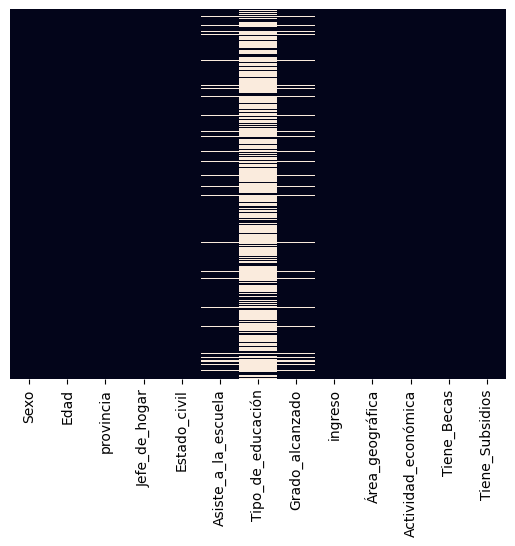

In [ ]:
# Distribución de nulos por medio del color blanco
sns.heatmap(df_clean.isnull(), cbar=False, yticklabels = False)

Para visualizar los valores nulos, nos ayudamos con este mapa de calor, marcándolos en blanco

# Recodificación de variables para mejor entendimiento

Se crean diccionarios para transformar los valores numéricos a sus respectivas categorías.

In [ ]:
dicc_sexo = {
    1: 'Masculino',
    2: 'Femenino',
}

df_clean.loc[:, 'Sexo'] = df_clean['Sexo'].replace(dicc_sexo).astype(str)

In [ ]:
dicc_jefe_h = {
    1: 'Jefe o jefa',
    2: 'Conyugue',
    3: 'Hijo o hija',
    4: 'Otro pariente',
    5: 'Servicio domestico'
}

df_clean.loc[:, 'Jefe_de_hogar'] = df_clean['Jefe_de_hogar'].replace(dicc_jefe_h).astype(str)

In [ ]:
dicc_provincia = {
    '01': 'Bocas del Toro',
    '02': 'Coclé',
    '03': 'Colón',
    '04': 'Chiriquí',
    '05': 'Darién',
    '06': 'Herrera',
    '07': 'Los Santos',
    '08': 'Panamá',
    '09': 'Veraguas',
    '10': 'Comarca Guna Yala',
    '11': 'Comarca Emberá-Wounaan',
    '12': 'Comarca Ngäbe-Buglé',
    '13': 'Panamá Oeste'
}

df_clean.loc[:, 'provincia'] = df_clean['provincia'].replace(dicc_provincia)

In [ ]:
dicc_e_civil = {
    1: 'Unido',
    2: 'Separado de matrimonio',
    3: 'Separado de unión',
    4: 'Casado',
    5: 'Divorciado',
    6: 'Viudo',
    7: 'Soltero',
    8: 'Menor de 15 años'
}

df_clean.loc[:, 'Estado_civil'] = df_clean['Estado_civil'].replace(dicc_e_civil).astype(str)

In [ ]:
dicc_asiste_a_la_escuela = {
    1: 'Sí',
    2: 'No'
}

df_clean.loc[:, 'Asiste_a_la_escuela'] = df_clean['Asiste_a_la_escuela'].replace(dicc_asiste_a_la_escuela).astype(str)

In [ ]:
dicc_asiste_a_la_escuela = {
    1: 'Sí',
    2: 'No'
}

df_clean.loc[:, 'Asiste_a_la_escuela'] = df_clean['Asiste_a_la_escuela'].replace(dicc_asiste_a_la_escuela)

In [ ]:
dicc_tiene_beca = {
    1: 'Sí',
    0: 'No'
}

df_clean.loc[:, 'Tiene_Becas'] = df_clean['Tiene_Becas'].replace(dicc_tiene_beca).astype(str)

In [ ]:
dicc_tipo_edu = {
    3: 'Oficial',
    4: 'Particular'
}

df_clean.loc[:, 'Tipo_de_educación'] = df_clean['Tipo_de_educación'].replace(dicc_tipo_edu).astype(str)

In [ ]:
dicc_nivel_edu = {
    1: 'Ningun grado',
    2: 'Prekínder o prejardín',
    3: 'Kínder o jardín',
    4: 'Enseñanza especial',
    11: 'Primaria',
    12: 'Primaria',
    13: 'Primaria',
    14: 'Primaria',
    15: 'Primaria',
    16: 'Primaria',
    21: 'Vocacional',
    22: 'Vocacional',
    23: 'Vocacional',
    31: 'Primer ciclo premedia',
    32: 'Primer ciclo premedia',
    33: 'Primer ciclo premedia',
    34: 'Segundo ciclo media',
    35: 'Segundo ciclo media',
    36: 'Segundo ciclo media',
    41: 'Superior no universitaria',
    42: 'Superior no universitaria',
    51: 'Superior universitario',
    52: 'Superior universitario',
    53: 'Superior universitario',
    54: 'Superior universitario',
    55: 'Superior universitario',
    56: 'Superior universitario',
    61: 'Especialidad postgrado',
    71: 'Maestria',
    72: 'Maestria',
    81: 'Doctorado',
    82: 'Doctorado',
    83: 'Doctorado',
    84: 'Doctorado',
}

df_clean['Nivel_educativo'] = df_clean['Grado_alcanzado'].replace(dicc_nivel_edu).astype(str)

Utilizamos una revisión general después de haber aplicado los diccionarios

In [ ]:
df_clean.head(10)

,Sexo,Edad,provincia,Jefe_de_hogar,Estado_civil,Asiste_a_la_escuela,Tipo_de_educación,Grado_alcanzado,ingreso,Área_geográfica,Actividad_económica,Tiene_Becas,Tiene_Subsidios,Nivel_educativo
0,Masculino,44.0,Bocas del Toro,Jefe o jefa,Unido,No,nan,53.0,,Urbana,08,No,0.0,Superior universitario
1,Femenino,21.0,Bocas del Toro,Conyugue,Unido,No,nan,36.0,07,Urbana,09,No,0.0,Segundo ciclo media
2,Masculino,4.0,Bocas del Toro,Hijo o hija,Menor de 15 años,No,nan,1.0,,Urbana,,No,0.0,Ningun grado
3,Femenino,22.0,Bocas del Toro,Jefe o jefa,Unido,No,nan,36.0,07,Urbana,09,No,0.0,Segundo ciclo media
4,Masculino,26.0,Bocas del Toro,Conyugue,Unido,No,nan,36.0,08,Urbana,09,No,0.0,Segundo ciclo media
5,Masculino,3.0,Bocas del Toro,Hijo o hija,Menor de 15 años,nan,nan,NaN,,Urbana,,No,0.0,nan
6,Femenino,34.0,Bocas del Toro,Jefe o jefa,Casado,No,nan,36.0,08,Urbana,15,No,0.0,Segundo ciclo media
7,Masculino,43.0,Bocas del Toro,Conyugue,Casado,No,nan,55.0,08,Urbana,15,No,0.0,Superior universitario
8,Femenino,16.0,Bocas del Toro,Hijo o hija,Soltero,Sí,Particular,34.0,,Urbana,,Sí,0.0,Segundo ciclo media
9,Femenino,56.0,Bocas del Toro,Otro pariente,Separado de unión,No,nan,36.0,06,Urbana,18,No,0.0,Segundo ciclo media


#Limpieza de datos faltantes

In [ ]:
df_clean['Tipo_de_educación'] = df_clean['Tipo_de_educación'].replace('nan', np.nan)
df_clean['Tipo_de_educación'] = df_clean['Tipo_de_educación'].fillna('No aplica')
df_clean['Grado_alcanzado'] = df_clean['Grado_alcanzado'].fillna('No aplica')

# Principales gráficos

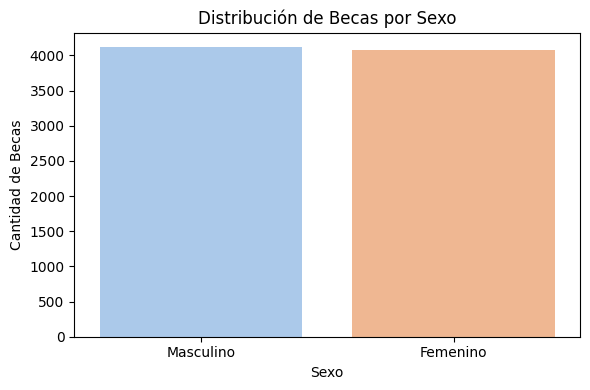

In [ ]:
df_becas = df_clean[df_clean['Tiene_Becas'] == 'Sí']

# Contar cuántas becas hay por sexo
becas_por_sexo = df_becas['Sexo'].value_counts()

# Crear gráfico
plt.figure(figsize=(6, 4))
sns.barplot(x=becas_por_sexo.index, y=becas_por_sexo.values, palette='pastel')
plt.title('Distribución de Becas por Sexo')
plt.xlabel('Sexo')
plt.ylabel('Cantidad de Becas')
plt.tight_layout()
plt.show()

Se observa que la cantidad de becas otorgadas se encuentra distribuída de manera equitativa medidas por el sexo del estudiante.

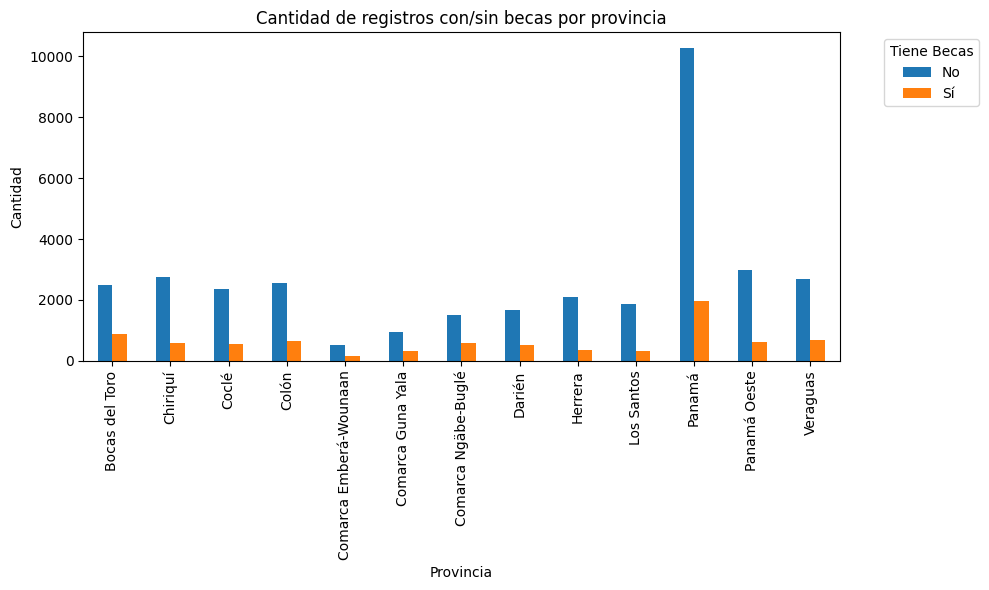

In [ ]:
# 3. Agrupar datos por provincia
conteo = df_clean.groupby(['provincia', 'Tiene_Becas']).size().unstack(fill_value=0)

# 4. Crear gráfico
ax = conteo.plot(kind='bar', stacked=False, figsize=(10, 6))

# 5. Ajustar leyenda fuera del gráfico
plt.legend(title='Tiene Becas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Cantidad de registros con/sin becas por provincia')
plt.xlabel('Provincia')
plt.ylabel('Cantidad')
plt.tight_layout()  # Ajusta automáticamente para que nada quede fuera
plt.show()

Se observa mayor distribución de becas en la provicina de Panamá, lo cual puede ser explicado debido a la densidad de la población en esta área, seguido de las provincias de Bocas del Toro, Colón y Veraguas.

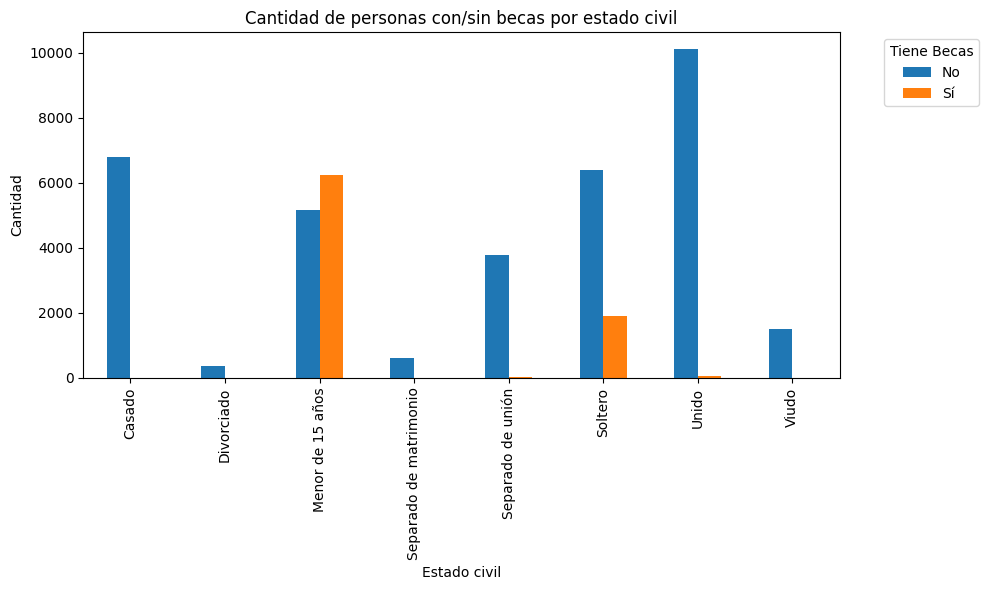

In [ ]:
# Agrupar datos por estado civil
conteo = df_clean.groupby(['Estado_civil', 'Tiene_Becas']).size().unstack(fill_value=0)

# Paso 4: Graficar
ax = conteo.plot(kind='bar', figsize=(10, 6))

# Paso 5: Mostrar leyenda fuera del gráfico
plt.legend(title='Tiene Becas', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.title('Cantidad de personas con/sin becas por estado civil')
plt.xlabel('Estado civil')
plt.ylabel('Cantidad')
plt.tight_layout()  # Asegura que la leyenda no se corte
plt.show()

El siguiente gráfico muestra que las personas menores de 15 años tienen mayor acceso a becas, seguido de los solteros.

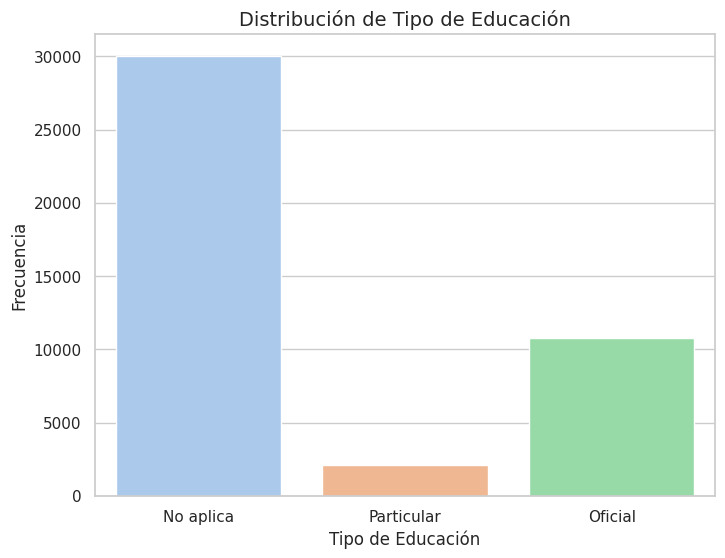

In [ ]:
sns.set(style="whitegrid")

# Crear una figura y un eje
plt.figure(figsize=(8, 6))

# Histograma categórico (countplot) de Tipo_de_educación
sns.countplot(data=df_clean, x="Tipo_de_educación", palette="pastel")

# Títulos y etiquetas
plt.title("Distribución de Tipo de Educación", fontsize=14)
plt.xlabel("Tipo de Educación")
plt.ylabel("Frecuencia")

# Mostrar el gráfico
plt.show()

Se observa que hay una desigualdad en la distribución. Claramente con mayoría de estudiantes en escuelas oficiales

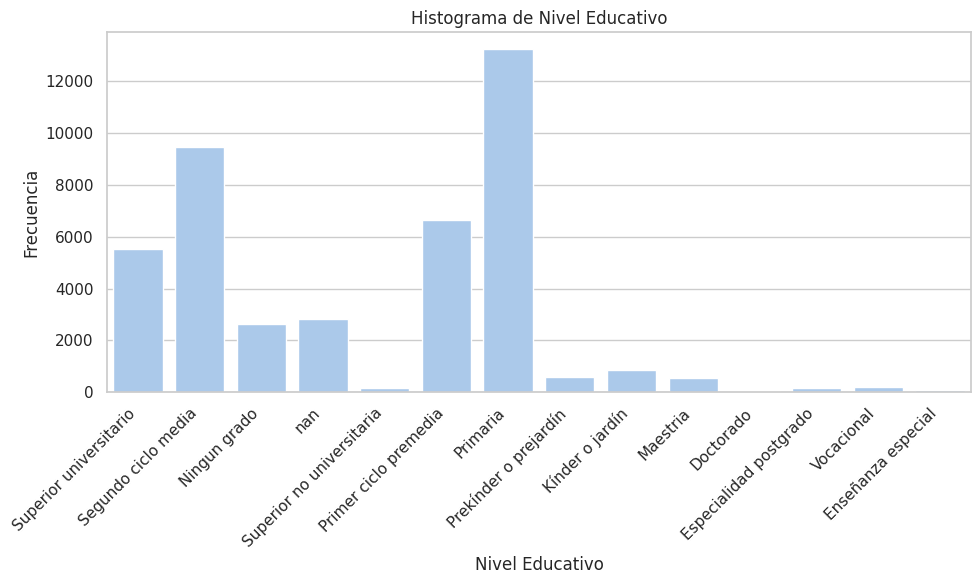

In [ ]:
sns.set(style="whitegrid", palette="pastel")

# Crear la figura
plt.figure(figsize=(10, 6))

# Histograma categórico (conteo de valores de Nivel_educativo)
sns.countplot(data=df_clean, x="Nivel_educativo")

# Título y etiquetas
plt.title("Histograma de Nivel Educativo", fontsize=12)
plt.xlabel("Nivel Educativo")
plt.ylabel("Frecuencia")

# Ajustar para que se vea todo correctamente
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# Mostrar el gráfico
plt.show()

Gráfica de cómo está distribuída educativamente la población

In [ ]:
# Verificar datos de df_clean
df_clean.head()

,Sexo,Edad,provincia,Jefe_de_hogar,Estado_civil,Asiste_a_la_escuela,Tipo_de_educación,Grado_alcanzado,ingreso,Área_geográfica,Actividad_económica,Tiene_Becas,Tiene_Subsidios,Nivel_educativo
0,Masculino,44.0,Bocas del Toro,Jefe o jefa,Unido,No,No aplica,53.0,,Urbana,08,No,0.0,Superior universitario
1,Femenino,21.0,Bocas del Toro,Conyugue,Unido,No,No aplica,36.0,07,Urbana,09,No,0.0,Segundo ciclo media
2,Masculino,4.0,Bocas del Toro,Hijo o hija,Menor de 15 años,No,No aplica,1.0,,Urbana,,No,0.0,Ningun grado
3,Femenino,22.0,Bocas del Toro,Jefe o jefa,Unido,No,No aplica,36.0,07,Urbana,09,No,0.0,Segundo ciclo media
4,Masculino,26.0,Bocas del Toro,Conyugue,Unido,No,No aplica,36.0,08,Urbana,09,No,0.0,Segundo ciclo media


In [ ]:
#Categorías que tiene cada una de las variables
for col in df_clean.columns:
    print(f"Categorías únicas para '{col}':")
    print(df_clean[col].dropna().unique())
    print("-" * 40)

Categorías únicas para 'Sexo':
['Masculino' 'Femenino']
----------------------------------------
Categorías únicas para 'Edad':
[ 44.  21.   4.  22.  26.   3.  34.  43.  16.  56.  59.  63.  31.  37.
  94.   9.  46.  91.  25.  75.  14.  11.  57.  48.  80.  71.  49.  13.
  10.  36.  15.  66.  54.  47.  42.  24.  19.  39.  29.  28.  17.  50.
  45.  23.  20.   5.   0.  18.  30.  33.   7.  38.  12.   8.  58.  61.
  78.  64.  74.   6.  40.  52.  32.  27.   1.   2.  51.  62.  77.  92.
  53.  60.  55.  68.  35.  41.  70.  67.  89.  96.  72.  82.  76.  69.
  65.  86.  73.  88.  84.  95.  87.  90.  99.  81.  97.  79.  83.  85.
  93.  98. 101. 108. 100. 104. 102. 107.]
----------------------------------------
Categorías únicas para 'provincia':
['Bocas del Toro' 'Coclé' 'Colón' 'Chiriquí' 'Darién' 'Herrera'
 'Los Santos' 'Panamá Oeste' 'Panamá' 'Veraguas' 'Comarca Guna Yala'
 'Comarca Emberá-Wounaan' 'Comarca Ngäbe-Buglé']
----------------------------------------
Categorías únicas para 'Jefe_de_h

In [ ]:
porcentajes = df['Asiste_a_la_escuela'].value_counts(dropna=False, normalize=True) * 100

# Mostrar resultados
print(porcentajes)

Asiste_a_la_escuela
2.0    63.403611
1.0    30.005824
NaN     6.590565
Name: proportion, dtype: float64


# Si ya se filtraron los datos arriba con la nueva variable df_clean, no es necesario volverlo a filtrar y podemos pasar al modelado

(42925, 14)


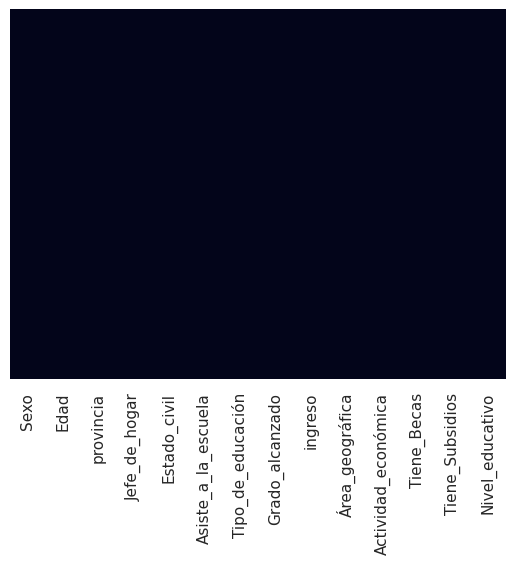

In [ ]:
# Distribución de nulos por medio del color blanco
sns.heatmap(df_clean.isnull(), cbar=False, yticklabels = False)

print(df_clean.shape)

# Selección de variables independientes X para los modelos y definición de variabla dependiente

In [ ]:
# Selección de variables para los modelos
X = df_clean[['Sexo', 'Jefe_de_hogar', 'Área_geográfica', 'Tipo_de_educación','Tiene_Subsidios','Actividad_económica','Edad','provincia','Grado_alcanzado','ingreso']]
y = df_clean['Tiene_Becas']

#Revisar de dónde se genera la variable X que llama a las variables de análisis en el estudio, o las variables independientes.


In [ ]:
#Ver cuántos NaN hay por variable en X
print(X.isnull().sum())

Sexo                   0
Jefe_de_hogar          0
Área_geográfica        0
Tipo_de_educación      0
Tiene_Subsidios        0
Actividad_económica    0
Edad                   0
provincia              0
Grado_alcanzado        0
ingreso                0
dtype: int64


#Transformación de variables dummy

In [ ]:
# Codificación con get_dummies
X = pd.get_dummies(X, drop_first=True)

#Prueba de 3 Modelos predictivos de machine learning (Árbol de Decisión, Random Forest y XGBoost)

AUC promedio Árbol de Decisión (validación cruzada): 0.9868
AUC promedio Random Forest (validación cruzada): 0.9894
AUC promedio XGBoost (validación cruzada): 0.9915

=== Árbol de Decisión ===
Matriz de confusión:
[[10045   302]
 [  127  2404]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     10347
           1       0.89      0.95      0.92      2531

    accuracy                           0.97     12878
   macro avg       0.94      0.96      0.95     12878
weighted avg       0.97      0.97      0.97     12878


=== Random Forest ===
Matriz de confusión:
[[10059   288]
 [  135  2396]]
Reporte de clasificación:
              precision    recall  f1-score   support

           0       0.99      0.97      0.98     10347
           1       0.89      0.95      0.92      2531

    accuracy                           0.97     12878
   macro avg       0.94      0.96      0.95     12878
weighted avg       0.97      

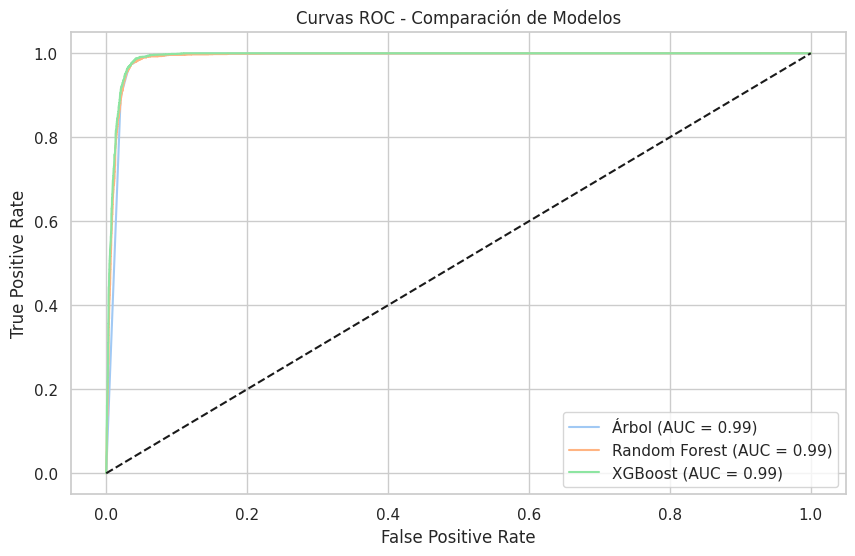

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

#Convertir las etiquetas 'Sí' y 'No' a 1 y 0
y = y.replace({'No': 0, 'Sí': 1})

# Separar en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# *************************** Definir los modelos *************************** #

#******* Decision Tree model ****** #
param_grid_tree = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10]
}

# Grid search para Decision Tree
grid_tree = GridSearchCV(DecisionTreeClassifier(random_state=42),
                         param_grid_tree, cv=5, scoring='roc_auc', n_jobs=-1)
grid_tree.fit(X_train, y_train)
best_tree = grid_tree.best_estimator_

print(f"AUC promedio Árbol de Decisión (validación cruzada): {grid_tree.best_score_:.4f}")


#******* Random Forest ****** #
param_grid_rf = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}

# Grid search para Random Forest
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42),
                       param_grid_rf, cv=5, scoring='roc_auc', n_jobs=-1)
grid_rf.fit(X_train, y_train)
best_rf = grid_rf.best_estimator_

print(f"AUC promedio Random Forest (validación cruzada): {grid_rf.best_score_:.4f}")

#******* XGBClasssifier ****** #
param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3]
}

# Grid search para XGBoost
grid_xgb = GridSearchCV(XGBClassifier(eval_metric='logloss', random_state=42),
                        param_grid_xgb, cv=5, scoring='roc_auc', n_jobs=-1)
grid_xgb.fit(X_train, y_train)
best_xgb = grid_xgb.best_estimator_

print(f"AUC promedio XGBoost (validación cruzada): {grid_xgb.best_score_:.4f}")

# Hacer predicciones
y_pred_tree = best_tree.predict(X_test)
y_pred_prob_tree = best_tree.predict_proba(X_test)[:, 1]

y_pred_rf = best_rf.predict(X_test)
y_pred_prob_rf = best_rf.predict_proba(X_test)[:, 1]

y_pred_xgb = best_xgb.predict(X_test)
y_pred_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# Evaluación
def evaluar_modelo(nombre, y_true, y_pred):
    print(f"\n=== {nombre} ===")
    print("Matriz de confusión:")
    print(confusion_matrix(y_true, y_pred))
    print("Reporte de clasificación:")
    print(classification_report(y_true, y_pred))

#evaluar_modelo("Regresión Logística", y_test, y_pred_log)
evaluar_modelo("Árbol de Decisión", y_test, y_pred_tree)
evaluar_modelo("Random Forest", y_test, y_pred_rf)
evaluar_modelo("XGBoost", y_test, y_pred_xgb)

# Curvas ROC
plt.figure(figsize=(10, 6))

modelos = [
    #("Logística", y_pred_prob_log),
    ("Árbol", y_pred_prob_tree),
    ("Random Forest", y_pred_prob_rf),
    ("XGBoost", y_pred_prob_xgb)
]

for nombre, probs in modelos:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    plt.plot(fpr, tpr, label=f'{nombre} (AUC = {auc:.2f})')

plt.plot([0, 1], [0, 1], 'k--')
plt.title('Curvas ROC - Comparación de Modelos')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.grid(True)
plt.show()


In [ ]:
print("Accuracy en entrenamiento, Árbol de desición:", best_tree.score(X_train, y_train))
print("Accuracy en prueba, Árbol de desición:", best_tree.score(X_test, y_test))

print("Accuracy en entrenamiento, Random Forest:", best_rf.score(X_train, y_train))
print("Accuracy en prueba, Random Forest:", best_rf.score(X_test, y_test))

print("Accuracy en entrenamiento, XGBoost:", best_xgb.score(X_train, y_train))
print("Accuracy en prueba, XGBoost", best_xgb.score(X_test, y_test))

Accuracy en entrenamiento, Árbol de desición: 0.9696142709754718
Accuracy en prueba, Árbol de desición: 0.9666873738158099
Accuracy en entrenamiento, Random Forest: 0.9804306586348055
Accuracy en prueba, Random Forest: 0.9671532846715328
Accuracy en entrenamiento, XGBoost: 0.9733750457616401
Accuracy en prueba, XGBoost 0.9683180618108402


#Peso probabilístico de cada variable

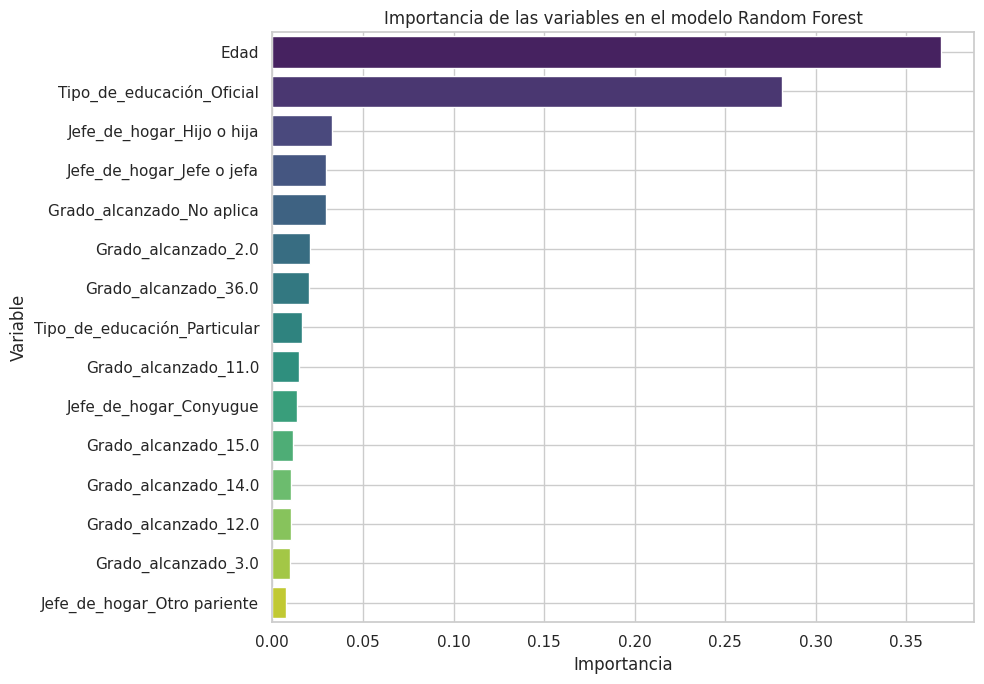

,Variable,Importancia
1,Edad,0.368854
9,Tipo_de_educación_Oficial,0.281379
4,Jefe_de_hogar_Hijo o hija,0.032882
5,Jefe_de_hogar_Jefe o jefa,0.029505
76,Grado_alcanzado_No aplica,0.029444
44,Grado_alcanzado_2.0,0.020791
61,Grado_alcanzado_36.0,0.020166
10,Tipo_de_educación_Particular,0.016378
47,Grado_alcanzado_11.0,0.014565
3,Jefe_de_hogar_Conyugue,0.013436


In [ ]:

# Gráfico de importancia de variables del modelo Random Forest entrenado con SMOTE

# Obtener importancias
importancias = best_rf.feature_importances_
nombres_variables = X.columns

# Crear DataFrame
df_importancias = pd.DataFrame({
    'Variable': nombres_variables,
    'Importancia': importancias
}).sort_values(by='Importancia', ascending=False)

# Graficar top 15
plt.figure(figsize=(10, 7))
sns.barplot(x='Importancia', y='Variable', data=df_importancias.head(15), palette='viridis')
plt.title('Importancia de las variables en el modelo Random Forest')
plt.xlabel('Importancia')
plt.ylabel('Variable')
plt.grid(True)
plt.tight_layout()
plt.show()

# Mostrar tabla
df_importancias.head(15)


#Predecir un ejemplo real

In [ ]:
# -------------------------------
# 1. Simulación de datos de entrenamiento
# -------------------------------
np.random.seed(42)
n = 5000

df = pd.DataFrame({
    'Sexo': np.random.choice(['Femenino', 'Masculino'], size=n),
    'Edad': np.random.randint(5, 99, size=n),
    'provincia': np.random.choice([
        'Bocas del Toro', 'Cocle', 'Colon', 'Chiriqui', 'Darien',
        'Herrera', 'Los Santos', 'Panama', 'Panama Oeste', 'Veraguas'
    ], size=n),
    'Estado_civil': np.random.choice([
        'Unido', 'Separado de matrimonio', 'Separado de unión', 'Casado',
        'Divorciado', 'Viudo', 'Soltero', 'Menor de 15 años'
    ], size=n),
    'Asiste_a_la_escuela': np.random.choice(['Sí', 'No'], size=n),
    'Tipo_de_educación': np.random.choice([3, 4], size=n),
    'Grado_alcanzado': np.random.choice([
        'Ningun grado',
        'Prekínder o prejardín',
        'Kínder o jardín',
        'Enseñanza especial',
        'Primaria',
        'Vocacional',
        'Primer ciclo premedia',
        'Segundo ciclo media',
        'Superior no universitaria',
        'Superior universitario',
        'Especialidad postgrado',
        'Maestria',
        'Doctorado',
    ], size=n),
    'Ingreso': np.random.randint(100, 1200, size=n),  # será reajustado más abajo
    'Área_geográfica': np.random.choice(['Urbana', 'Rural'], size=n),
    'Actividad_económica': np.random.choice([
        'Agricultura ganadería silvicultura',
        'Explotación de minas y canteras',
        'Industrias manufactureras',
        'Suministro de Electricidad gas vapor',
        'Suministro de agua',
        'Construcción',
        'Comercio al por mayor y al por menor',
        'Transporte y almacenamiento',
        'Hoteles y restaurantes',
        'Información y comunicaciones',
        'Actividades Financieras y seguros',
        'Actividades Inmobiliarias',
        'Actividades Profesionales científicas y técnicas',
        'Actividades de servicios administrativas',
        'Administración Pública',
        'Enseñanza',
        'Actividad de atención de la Salud',
        'Actividad artística',
        'Otras Actividades de servicio',
        'Actividades de los Hogares',
        'Actividades de Organizaciones'
    ], size=n),
    'Tiene_Becas': np.random.choice(['Sí', 'No'], size=n)
})

# ----------------------
# 2. Correcciones y validaciones de coherencia
# ----------------------

# Corregir edad y grado si Estado_civil = "Menor de 15 años"
grados_menores = [
    'Ningun grado',
    'Prekínder o prejardín',
    'Kínder o jardín',
    'Enseñanza especial',
    'Primaria',
    'Primer ciclo premedia'
]

idx_menores = df[df['Estado_civil'] == 'Menor de 15 años'].index
df.loc[idx_menores, 'Edad'] = np.random.randint(1, 15, size=len(idx_menores))
df.loc[idx_menores, 'Grado_alcanzado'] = np.random.choice(grados_menores, size=len(idx_menores))

# Asegurar edades mínimas según grado académico
df.loc[(df['Grado_alcanzado'].isin(['Doctorado', 'Maestria', 'Especialidad postgrado'])) & (df['Edad'] < 23), 'Edad'] = np.random.randint(23, 30)
df.loc[(df['Grado_alcanzado'].isin(['Superior universitario', 'Superior no universitaria'])) & (df['Edad'] < 18), 'Edad'] = np.random.randint(18, 23)

# Si edad < 15 → sin ingreso ni actividad económica
idx_niños = df[df['Edad'] < 15].index
df.loc[idx_niños, 'Ingreso'] = 0
df.loc[idx_niños, 'Actividad_económica'] = 'Ninguna'

# Si Tiene_Becas == 'Sí' ⇒ Asiste_a_la_escuela debe ser 'Sí'
df.loc[df['Tiene_Becas'] == 'Sí', 'Asiste_a_la_escuela'] = 'Sí'

# Ajustar Ingreso según nivel educativo
def ingreso_por_grado(grado):
    if grado in ['Doctorado', 'Maestria', 'Especialidad postgrado']:
        return np.random.randint(800, 1200)
    elif grado in ['Superior universitario', 'Superior no universitaria']:
        return np.random.randint(600, 1000)
    elif grado in ['Segundo ciclo media', 'Primer ciclo premedia']:
        return np.random.randint(400, 800)
    elif grado in ['Primaria', 'Vocacional']:
        return np.random.randint(200, 600)
    elif grado in grados_menores:
        return np.random.randint(0, 200)
    else:
        return 0

df['Ingreso'] = df.apply(lambda row: ingreso_por_grado(row['Grado_alcanzado']) if row['Edad'] >= 15 else 0, axis=1)

# Asegurar que menores de edad no tengan estados civiles incoherentes
estados_mayores = [
    'Unido', 'Separado de matrimonio', 'Separado de unión',
    'Casado', 'Divorciado', 'Viudo', 'Soltero'
]

# a. Menores de 15 años → Estado_civil = 'Menor de 15 años'
df.loc[df['Edad'] < 15, 'Estado_civil'] = 'Menor de 15 años'

# b. Entre 15 y 17 → Solo 'Soltero'
df.loc[(df['Edad'] >= 15) & (df['Edad'] < 18), 'Estado_civil'] = 'Soltero'

# c. Mayores de 18 → asegurar que no tengan 'Menor de 15 años'
df.loc[df['Edad'] >= 18, 'Estado_civil'] = np.random.choice(estados_mayores, size=(df['Edad'] >= 18).sum())

# Etiqueta binaria
df['Tiene_Becas'] = df['Tiene_Becas'].replace({'Sí': 1, 'No': 0})
y = df['Tiene_Becas']

# Variables predictoras
X = df.drop(columns=['Tiene_Becas'])

# Codificación
X_encoded = pd.get_dummies(X, drop_first=True)
X_columns = X_encoded.columns.tolist()



# -------------------------------
# 3. Nuevos datos a predecir
# -------------------------------
nuevos_datos = df.drop(columns=['Tiene_Becas']).sample(1000, random_state=42)

# -------------------------------
# 4. Codificar igual que el modelo
# -------------------------------
nuevos_encoded = pd.get_dummies(nuevos_datos, drop_first=True)

# Asegurar que tenga las mismas columnas que X_encoded
for col in X_columns:
    if col not in nuevos_encoded:
        nuevos_encoded[col] = 0

# Ordenar columnas igual que en el modelo
nuevos_encoded = nuevos_encoded[X_columns]

# -------------------------------
# 5. Aplicar modelo y calcular score
# -------------------------------
nuevos_datos['Probabilidad_Beca'] = best_rf.predict_proba(nuevos_encoded)[:, 1]
nuevos_datos['Score_Becabilidad (%)'] = (nuevos_datos['Probabilidad_Beca'] * 100).round(2)

# Mostrar resultados
print(nuevos_datos)

# Guardar en Excel
nuevos_datos.to_excel("score_becabilidad_nuevos.xlsx", index=False)

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Actividad_económica_Actividad de atención de la Salud
- Actividad_económica_Actividades Financieras y seguros
- Actividad_económica_Actividades Inmobiliarias
- Actividad_económica_Actividades Profesionales científicas y técnicas
- Actividad_económica_Actividades de Organizaciones
- ...
Feature names seen at fit time, yet now missing:
- Actividad_económica_01
- Actividad_económica_02
- Actividad_económica_03
- Actividad_económica_04
- Actividad_económica_05
- ...
